## Predictive Analysis and XAI(Explainable AI)


In [2]:
!pip install pandas numpy matplotlib scikit-learn seaborn 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
"""
- Load raw artist data
- Understand structure and data types
- Identify immediate issues (nulls, duplicates, etc.)
"""
df_artists = pd.read_csv('../dataset/artists.csv',sep=None, index_col=0, engine='python', encoding='utf-8')

print("ARTIST DATASET::\n")
print(f"- {df_artists.shape[0]} rows {df_artists.shape[1]} columns\n")
print(f"- {df_artists.info()}\n")
print(f"- {df_artists.describe(include="all")}")
df_artists.head()

ARTIST DATASET::

- 104 rows 13 columns

<class 'pandas.core.frame.DataFrame'>
Index: 104 entries, ART82291002 to ART83631935
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          104 non-null    object 
 1   gender        104 non-null    object 
 2   birth_date    73 non-null     object 
 3   birth_place   72 non-null     object 
 4   nationality   71 non-null     object 
 5   description   86 non-null     object 
 6   active_start  50 non-null     object 
 7   active_end    0 non-null      float64
 8   province      70 non-null     object 
 9   region        68 non-null     object 
 10  country       70 non-null     object 
 11  latitude      72 non-null     float64
 12  longitude     72 non-null     float64
dtypes: float64(3), object(10)
memory usage: 11.4+ KB
- None

-             name gender  birth_date birth_place nationality  \
count        104    104          73          72          71   
unique

,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
id_author,,,,,,,,,,,,,
ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,NaN,NaN,NaN,NaN
ART53496045,achille lauro,M,1990-07-11,Verona,Italia,cantautore e rapper italiano (1990-),2012-01-01,NaN,Verona,Veneto,Italia,45.442498,10.985738
ART18853907,alfa,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ART64265460,anna pepe,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ART75741740,articolo 31,M,NaN,NaN,NaN,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
"""
Purpose:
- Quantify missing data per column
- Specifically check 'region' column (critical for our task!)
- Decide on strategy: drop, impute, or collect missing data
"""

missing_stats = pd.DataFrame({
    'Column': df_artists.columns,
    'Missing_Count': df_artists.isnull().sum(),
    'Missing_Percentage': (df_artists.isnull().sum() / len(df_artists)) * 100
})

missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', 
    ascending=False
)

print(missing_stats.to_string(index=False))
region_missing = df_artists['region'].isnull().sum()
region_missing_pct = (region_missing / len(df_artists)) * 100

print(region_missing)
print(region_missing_pct)

      Column  Missing_Count  Missing_Percentage
  active_end            104          100.000000
active_start             54           51.923077
      region             36           34.615385
    province             34           32.692308
     country             34           32.692308
 nationality             33           31.730769
 birth_place             32           30.769231
    latitude             32           30.769231
   longitude             32           30.769231
  birth_date             31           29.807692
 description             18           17.307692
36
34.61538461538461


In [6]:
"""
Determine strategy for handling missing regions based on percentage of missing data.
If <10% missing, we can drop. If 10-40%, investigate manually. If >40%, must collect data.
"""

if region_missing_pct < 10:
    print("Missing < 10% → Safe to drop NULL regions")
    strategy = "DROP"
elif 10 <= region_missing_pct < 40:
    print("Missing 10-40% → Consider manual lookup for major artists")
    strategy = "INVESTIGATE"
else:
    print("Missing ≥ 40% → MANDATORY data collection (scraping/manual)")
    strategy = "COLLECT"

print(f"\nRecommended strategy: {strategy}")

# Check which artists have missing regions
if region_missing > 0:
    print("SAMPLE OF ARTISTS WITH MISSING REGIONS:")
    artists_no_region = df_artists[df_artists['region'].isnull()]
    print(artists_no_region[['name']].head(10))


Missing 10-40% → Consider manual lookup for major artists

Recommended strategy: INVESTIGATE
SAMPLE OF ARTISTS WITH MISSING REGIONS:
                    name
id_author               
ART82291002     99 posse
ART18853907         alfa
ART64265460    anna pepe
ART75741740  articolo 31
ART40229749       baby k
ART19605256         beba
ART02666525      bigmama
ART03111237       brusco
ART95365016     bushwaka
ART28846313       caneda


In [7]:
"""
Fill missing artist regions with manually researched data from Wikipedia, Genius.com, and artist biographies.
Track data provenance using 'region_source' column to distinguish between original and manually filled regions.
"""

df_artists = df_artists.copy()
df_artists['region_source'] = 'original'

region_missing_before = df_artists['region'].isnull().sum()
region_missing_pct = (region_missing_before / len(df_artists)) * 100

print(f"Before imputation:")
print(f"Total artists: {len(df_artists)}")
print(f"Artists with NULL region: {region_missing_before}")
print(f"Percentage missing: {region_missing_pct:.2f}%")

manual_artist_regions = {
    "99 posse": "Campania",
    "alfa": "Liguria",
    "anna pepe": "Liguria",
    "articolo 31": "Lombardia",
    "baby k": "Lazio",
    "beba": "Piemonte",
    "bigmama": "Campania",
    "brusco": "Lazio",
    "bushwaka": "Liguria",
    "caneda": "Lombardia",
    "club dogo": "Lombardia",
    "colle der fomento": "Lazio",
    "cor veleno": "Lazio",
    "dargen d_amico": "Lombardia",
    "dark polo gang": "Lazio",
    "doll kill": "Sardegna",
    "eva rea": "Sicilia",
    "fabri fibra": "Marche",
    "guè pequeno": "Lombardia",
    "hindaco": "Lombardia",
    "joey funboy": "Trentino-Alto Adige",
    "johnny marsiglia": "Sicilia",
    "mike24": "Liguria",
    "miss keta": "Lombardia",
    "miss simpatia": "Lazio",
    "mistico": "Lombardia",
    "nerone": "Lombardia",
    "nesli": "Marche",
    "o zulù": "Campania",
    "priestess": "Puglia",
    "samuel heron": "Liguria",
    "shablo": "Umbria",
    "shiva": "Lombardia",
    "skioffi": "Lazio",
    "sottotono": "Lombardia",
    "yeиdry": "Piemonte"
}

print(f"\nManual mapping contains {len(manual_artist_regions)} artists")

artists_with_null_region = df_artists[df_artists['region'].isnull()].copy()

if len(artists_with_null_region) > 0:
    print("IMPUTATION PROCESS:")
    
    imputed_count = 0
    not_found_artists = []
    
    for idx in artists_with_null_region.index:
        artist_name = df_artists.loc[idx, 'name']
        artist_name_normalized = artist_name.lower().strip()
        
        if artist_name_normalized in manual_artist_regions:
            region = manual_artist_regions[artist_name_normalized]
            df_artists.loc[idx, 'region'] = region
            df_artists.loc[idx, 'region_source'] = 'manual'
            imputed_count += 1
            print(f"Imputed: {artist_name} -> {region}")
        else:
            not_found_artists.append(artist_name)
    
    print(f"\nSuccessfully imputed {imputed_count} artists")
    
    if len(not_found_artists) > 0:
        print(f"\n{len(not_found_artists)} artists still have NULL regions")
        print("Dropping remaining NULL regions")
        df_artists = df_artists.dropna(subset=['region'])

region_missing_after = df_artists['region'].isnull().sum()

print("\nIMPUTATION RESULTS:")
print(f"Null regions before: {region_missing_before}")
print(f"Null regions after: {region_missing_after}")
print(f"Regions filled manually: {imputed_count}")
print(f"Cleaned artists shape: {df_artists.shape}")


Before imputation:
Total artists: 104
Artists with NULL region: 36
Percentage missing: 34.62%

Manual mapping contains 36 artists
IMPUTATION PROCESS:
Imputed: 99 posse -> Campania
Imputed: alfa -> Liguria
Imputed: anna pepe -> Liguria
Imputed: articolo 31 -> Lombardia
Imputed: baby k -> Lazio
Imputed: beba -> Piemonte
Imputed: bigmama -> Campania
Imputed: brusco -> Lazio
Imputed: bushwaka -> Liguria
Imputed: caneda -> Lombardia
Imputed: club dogo -> Lombardia
Imputed: colle der fomento -> Lazio
Imputed: cor veleno -> Lazio
Imputed: dargen d_amico -> Lombardia
Imputed: dark polo gang -> Lazio
Imputed: doll kill -> Sardegna
Imputed: eva rea -> Sicilia
Imputed: fabri fibra -> Marche
Imputed: guè pequeno -> Lombardia
Imputed: hindaco -> Lombardia
Imputed: joey funboy -> Trentino-Alto Adige
Imputed: johnny marsiglia -> Sicilia
Imputed: mike24 -> Liguria
Imputed: miss keta -> Lombardia
Imputed: miss simpatia -> Lazio
Imputed: mistico -> Lombardia
Imputed: nerone -> Lombardia
Imputed: nesli -

In [8]:
"""
Validate that manually imputed regions are valid Italian regions and consistent with existing data.
Check for typos or new regions introduced by manual imputation.
"""

all_regions = df_artists['region'].unique()
print(f"Unique regions in dataset: {len(all_regions)}")
print(sorted(all_regions))

manually_imputed = df_artists[df_artists['region_source'] == 'manual']

if len(manually_imputed) > 0:
    manual_regions_used = manually_imputed['region'].unique()
    print(f"\nRegions used in manual imputation: {sorted(manual_regions_used)}")
    
    original_regions = df_artists[df_artists['region_source'] == 'original']['region'].unique()
    new_regions = set(manual_regions_used) - set(original_regions)
    
    if len(new_regions) > 0:
        print(f"\nNew regions introduced by manual imputation:")
        print(sorted(new_regions))
    else:
        print("\nAll manually imputed regions already exist in original data")


Unique regions in dataset: 15
['Calabria', 'Campania', 'Emilia-Romagna', 'Lazio', 'Liguria', 'Lombardia', 'Marche', 'Piemonte', 'Puglia', 'Sardegna', 'Sicilia', 'Toscana', 'Trentino-Alto Adige', 'Umbria', 'Veneto']

Regions used in manual imputation: ['Campania', 'Lazio', 'Liguria', 'Lombardia', 'Marche', 'Piemonte', 'Puglia', 'Sardegna', 'Sicilia', 'Trentino-Alto Adige', 'Umbria']

New regions introduced by manual imputation:
['Trentino-Alto Adige', 'Umbria']


In [9]:
"""
Remove unnecessary columns from artists dataset that won't be used for prediction.
Keep only region and region_source for merging with tracks data later.
"""

columns_to_drop_artists = [
    'name', 'gender', 'birth_date', 'birth_place', 'nationality', 
    'description', 'active_start', 'active_end', 'province', 
    'country', 'latitude', 'longitude'
]

cols_to_drop = [c for c in columns_to_drop_artists if c in df_artists.columns]

print(f"Columns to drop: {cols_to_drop}")
df_artists = df_artists.drop(columns=cols_to_drop)

print(f"Remaining columns: {df_artists.columns.tolist()}")
print(f"Artists shape: {df_artists.shape}")
print(df_artists.head(10))


Columns to drop: ['name', 'gender', 'birth_date', 'birth_place', 'nationality', 'description', 'active_start', 'active_end', 'province', 'country', 'latitude', 'longitude']
Remaining columns: ['region', 'region_source']
Artists shape: (104, 2)
                region region_source
id_author                           
ART82291002   Campania        manual
ART53496045     Veneto      original
ART18853907    Liguria        manual
ART64265460    Liguria        manual
ART75741740  Lombardia        manual
ART24123617  Lombardia      original
ART40229749      Lazio        manual
ART56320683  Lombardia      original
ART19605256   Piemonte        manual
ART02666525   Campania        manual


In [10]:
df_artists.isnull().sum()

region           0
region_source    0
dtype: int64

In [11]:
## Analyse the region distribution

region_counts = df_artists["region"].value_counts().sort_values(ascending=False)

In [12]:
"""
Analyze distribution statistics of artists across regions to understand data balance.
"""

print(f"Total unique regions: {df_artists['region'].nunique()}")
print(f"Most common region: {region_counts.index[0]} ({region_counts.iloc[0]} artists)")
print(f"Least common region: {region_counts.index[-1]} ({region_counts.iloc[-1]} artists)")
print(f"Mean artists per region: {region_counts.mean():.2f}")
print(f"Median artists per region: {region_counts.median():.2f}")


Total unique regions: 15
Most common region: Lombardia (35 artists)
Least common region: Calabria (1 artists)
Mean artists per region: 6.93
Median artists per region: 3.00


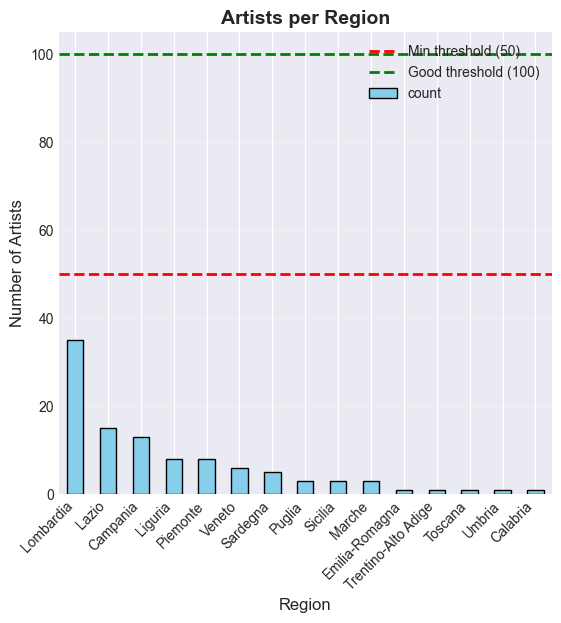

In [13]:
"""
Visualize artist distribution across regions with bar plot showing thresholds for data adequacy.
"""

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
region_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Artists per Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=50, color='red', linestyle='--', label='Min threshold (50)', linewidth=2)
plt.axhline(y=100, color='green', linestyle='--', label='Good threshold (100)', linewidth=2)
plt.legend()
plt.grid(axis='y', alpha=0.3)


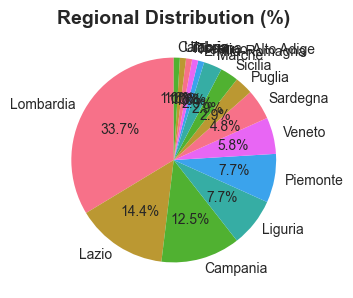

In [14]:
"""
Display pie chart showing percentage distribution of artists across regions.
"""

plt.subplot(1, 2, 2)
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Regional Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('regional_distribution_artists.png', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
"""
Load tracks dataset and inspect structure, data types, and missing values.
"""

df_tracks = pd.read_csv('../dataset/cleaned_tracks.csv', sep=None, engine='python', encoding='utf-8')

print("TRACKS DATASET - INITIAL INSPECTION")
print(f"Shape: {df_tracks.shape[0]} rows × {df_tracks.shape[1]} columns")
print(f"\nMissing values per column:")
missing_tracks = df_tracks.isnull().sum()
missing_tracks = missing_tracks[missing_tracks > 0].sort_values(ascending=False)
if len(missing_tracks) > 0:
    print(missing_tracks)
else:
    print("✓ No missing values!")

print(f"\nFirst 5 rows:")
print(df_tracks.head())


TRACKS DATASET - INITIAL INSPECTION
Shape: 11158 rows × 45 columns

Missing values per column:
featured_artists       7642
stats_pageviews        6521
album                  1513
year                   1026
day                     618
month                   538
album_release_date      339
language                128
lyrics                  128
album_type               78
id_album                 78
album_image              78
popularity               78
duration_ms              78
track_number             78
disc_number              78
album_name               78
rolloff                  66
bpm                      66
loudness                 66
pitch                    66
spectral_complexity      66
centroid                 66
zcr                      66
rms                      66
flux                     64
flatness                 64
dtype: int64

First 5 rows:
         id    id_artist    name_artist  \
0  TR934808  ART04205421  Rosa Chemical   
1  TR760029  ART04205421  Rosa Chem

In [16]:
"""
Impute missing values in tracks dataset using appropriate methods for each feature type.
Use median for audio features (robust to outliers) and mode for year (most common value).
"""

# Analyze missing values
missing_analysis = pd.DataFrame({
    'Column': df_tracks.columns,
    'Missing_Count': df_tracks.isnull().sum(),
    'Missing_Percentage': (df_tracks.isnull().sum() / len(df_tracks)) * 100,
    'Dtype': df_tracks.dtypes
})

missing_analysis = missing_analysis[missing_analysis['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_analysis) > 0:
    print("Columns with missing values:")
    print(missing_analysis.to_string(index=False))
    
    print("\nIMPUTATION PROCESS:")
    imputation_log = {}
    
    for idx, row in missing_analysis.iterrows():
        col = row['Column']
        missing_count = row['Missing_Count']
        pct = row['Missing_Percentage']
        
        if pct > 50:
            print(f"{col}: {pct:.2f}% missing → DROPPED")
            df_tracks = df_tracks.drop(columns=[col])
            imputation_log[col] = {'method': 'DROPPED', 'reason': 'Too much missing'}
        else:
            if col == 'year':
                impute_value = df_tracks[col].mode()[0]
                df_tracks[col].fillna(impute_value, inplace=True)
                print(f"✓ {col}: Imputed with MODE = {int(impute_value)}")
                imputation_log[col] = {'method': 'mode', 'value': int(impute_value), 'count': missing_count}
            
            elif col in ['bpm', 'centroid', 'rolloff', 'flux', 'rms', 'zcr', 'flatness', 
                         'spectral_complexity', 'pitch', 'loudness', 'duration_ms']:
                impute_value = df_tracks[col].median()
                df_tracks[col].fillna(impute_value, inplace=True)
                print(f"✓ {col}: Imputed with MEDIAN = {impute_value:.2f}")
                imputation_log[col] = {'method': 'median', 'value': impute_value, 'count': missing_count}
            
            elif row['Dtype'] in ['float64', 'int64']:
                impute_value = df_tracks[col].median()
                df_tracks[col].fillna(impute_value, inplace=True)
                print(f"✓ {col}: Imputed with MEDIAN = {impute_value:.2f}")
                imputation_log[col] = {'method': 'median', 'value': impute_value, 'count': missing_count}
            
            else:
                impute_value = df_tracks[col].mode()[0]
                df_tracks[col].fillna(impute_value, inplace=True)
                print(f"✓ {col}: Imputed with MODE = {impute_value}")
                imputation_log[col] = {'method': 'mode', 'value': impute_value, 'count': missing_count}
    
    print(f"\n✓ Remaining null values: {df_tracks.isnull().sum().sum()}")
    print(f"✓ Final tracks shape: {df_tracks.shape}")
else:
    print("✓ No missing values in tracks dataset!")


Columns with missing values:
             Column  Missing_Count  Missing_Percentage   Dtype
   featured_artists           7642           68.488977  object
    stats_pageviews           6521           58.442373 float64
              album           1513           13.559778  object
               year           1026            9.195196 float64
                day            618            5.538627 float64
              month            538            4.821653 float64
 album_release_date            339            3.038179  object
           language            128            1.147159  object
             lyrics            128            1.147159  object
         album_type             78            0.699050  object
           id_album             78            0.699050  object
        album_image             78            0.699050  object
         popularity             78            0.699050 float64
        duration_ms             78            0.699050 float64
       track_number       

/var/folders/29/j2385crd6f5dyk4l3185qktm0000gn/T/ipykernel_79300/4003801964.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_tracks[col].fillna(impute_value, inplace=True)
/var/folders/29/j2385crd6f5dyk4l3185qktm0000gn/T/ipykernel_79300/4003801964.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [17]:
"""
Verify that all missing values have been successfully imputed.
"""

print(f"Total null values remaining: {df_tracks.isnull().sum().sum()}")
if df_tracks.isnull().sum().sum() == 0:
    print("SUCCESS: All missing values imputed!")
else:
    print("WARNING: Some nulls remain")
    print(df_tracks.isnull().sum()[df_tracks.isnull().sum() > 0])


Total null values remaining: 0
SUCCESS: All missing values imputed!


In [18]:
"""
Remove columns that are not predictive or may cause data leakage from tracks dataset.
Keep only audio features, lyrical features, year, duration, explicit flag, and id_artist for merging.
"""

columns_to_drop_tracks = [
    'id', 'id_album', 'title', 'full_title', 'lyrics', 'featured_artists', 
    'primary_artist', 'swear_IT_words', 'swear_EN_words', 'album', 'album_name', 
    'album_image', 'album_release_date', 'album_type', 'disc_number', 'track_number',
    'stats_pageviews', 'popularity', 'modified_popularity', 'language', 'month', 'day'
]

cols_to_drop_tracks = [c for c in columns_to_drop_tracks if c in df_tracks.columns]
df_tracks = df_tracks.drop(columns=cols_to_drop_tracks)

print(f"✓ Remaining features ({len(df_tracks.columns)}):")
print(df_tracks.columns.tolist())
print(f"\n✓ Tracks shape: {df_tracks.shape}")
print(df_tracks.head())


✓ Remaining features (23):
['id_artist', 'name_artist', 'swear_IT', 'swear_EN', 'year', 'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'zcr', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'duration_ms', 'explicit']

✓ Tracks shape: (11158, 23)
     id_artist    name_artist  swear_IT  swear_EN    year  n_sentences  \
0  ART04205421  Rosa Chemical        16         6  2021.0          102   
1  ART04205421  Rosa Chemical        10        12  2020.0           56   
2  ART04205421  Rosa Chemical        18        11  2021.0           88   
3  ART04205421  Rosa Chemical         8         3  2019.0           37   
4  ART04205421  Rosa Chemical         1         0  2020.0           48   

   n_tokens  tokens_per_sent  char_per_tok  lexical_density  \
0       911         8.931373      4.170455         0.575284   
1       675        12.053571      4.280851         0.648936   
2       7

In [19]:
"""
Final verification that tracks dataset has no missing values after imputation and feature selection.
"""

print("Null values in tracks dataset:")
print(df_tracks.isnull().sum())
print(f"\nTotal nulls: {df_tracks.isnull().sum().sum()}")


Null values in tracks dataset:
id_artist               0
name_artist             0
swear_IT                0
swear_EN                0
year                    0
n_sentences             0
n_tokens                0
tokens_per_sent         0
char_per_tok            0
lexical_density         0
avg_token_per_clause    0
bpm                     0
centroid                0
rolloff                 0
flux                    0
rms                     0
zcr                     0
flatness                0
spectral_complexity     0
pitch                   0
loudness                0
duration_ms             0
explicit                0
dtype: int64

Total nulls: 0


In [20]:
"""
Merge artists and tracks datasets using inner join on artist ID.
This creates one dataset where each row is a song with its features and the artist's region.
"""

print("MERGING DATASETS")
print(f"\nBefore merge:")
print(f"Artists: {df_artists.shape}")
print(f"Tracks: {df_tracks.shape}")

# Merge on artist ID
df_merged = pd.merge(
    df_tracks,
    df_artists,
    left_on='id_artist',
    right_index=True,
    how='inner'
)

print(f"\n✓ After merge: {df_merged.shape}")
print(f"Songs before merge: {len(df_tracks)}")
print(f"Songs after merge: {len(df_merged)}")
print(f"Songs lost: {len(df_tracks) - len(df_merged)}")

print(f"\n✓ Merged columns: {df_merged.columns.tolist()}")
print(f"\nFirst 5 rows of merged dataset:")
print(df_merged.head())


MERGING DATASETS

Before merge:
Artists: (104, 2)
Tracks: (11158, 23)

✓ After merge: (11158, 25)
Songs before merge: 11158
Songs after merge: 11158
Songs lost: 0

✓ Merged columns: ['id_artist', 'name_artist', 'swear_IT', 'swear_EN', 'year', 'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'zcr', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'duration_ms', 'explicit', 'region', 'region_source']

First 5 rows of merged dataset:
     id_artist    name_artist  swear_IT  swear_EN    year  n_sentences  \
0  ART04205421  Rosa Chemical        16         6  2021.0          102   
1  ART04205421  Rosa Chemical        10        12  2020.0           56   
2  ART04205421  Rosa Chemical        18        11  2021.0           88   
3  ART04205421  Rosa Chemical         8         3  2019.0           37   
4  ART04205421  Rosa Chemical         1         0  2020.0           48   

   n_tokens 

In [21]:
######## Data Preprocessing Pre-Training

In [22]:
"""
Create 3-class balanced macro-zones by merging South+Islands with Central regions.
Target: Achieve near-perfect balance (<2:1 ratio) for optimal model performance.
"""

# THREE-CLASS BALANCED MAPPING
macro_zone_mapping_final = {
    # Lombardia standalone (cultural/economic hub)
    'Lombardia': 'Lombardia',
    
    # North + Center (Northern/Central Italy)
    'Piemonte': 'North_Center',
    'Veneto': 'North_Center',
    'Liguria': 'North_Center',
    'Emilia-Romagna': 'North_Center',
    'Trentino-Alto Adige': 'North_Center',
    'Toscana': 'North_Center',
    'Marche': 'North_Center',
    'Umbria': 'North_Center',
    
    # Center-South-Islands (Everything below Tuscany)
    'Lazio': 'Center_South_Islands',
    'Campania': 'Center_South_Islands',
    'Puglia': 'Center_South_Islands',
    'Calabria': 'Center_South_Islands',
    'Sicilia': 'Center_South_Islands',
    'Sardegna': 'Center_South_Islands'
}

# Apply mapping
df_merged['macro_zone'] = df_merged['region'].map(macro_zone_mapping_final)

# Check new distribution
macro_zone_counts = df_merged['macro_zone'].value_counts().sort_values(ascending=False)

print("THREE-CLASS MACRO-ZONE DISTRIBUTION (OPTIMAL BALANCE)")

print(macro_zone_counts)

# Calculate new imbalance
new_imbalance = macro_zone_counts.max() / macro_zone_counts.min()
print(f"\nImbalance ratio: {new_imbalance:.2f}:1")

if new_imbalance < 2:
    print("PERFECT BALANCE! (<2:1)")
elif new_imbalance < 3:
    print(" EXCELLENT BALANCE! (2-3:1)")
else:
    print("Still moderate imbalance")

THREE-CLASS MACRO-ZONE DISTRIBUTION (OPTIMAL BALANCE)
macro_zone
Center_South_Islands    4393
Lombardia               4184
North_Center            2581
Name: count, dtype: int64

Imbalance ratio: 1.70:1
PERFECT BALANCE! (<2:1)


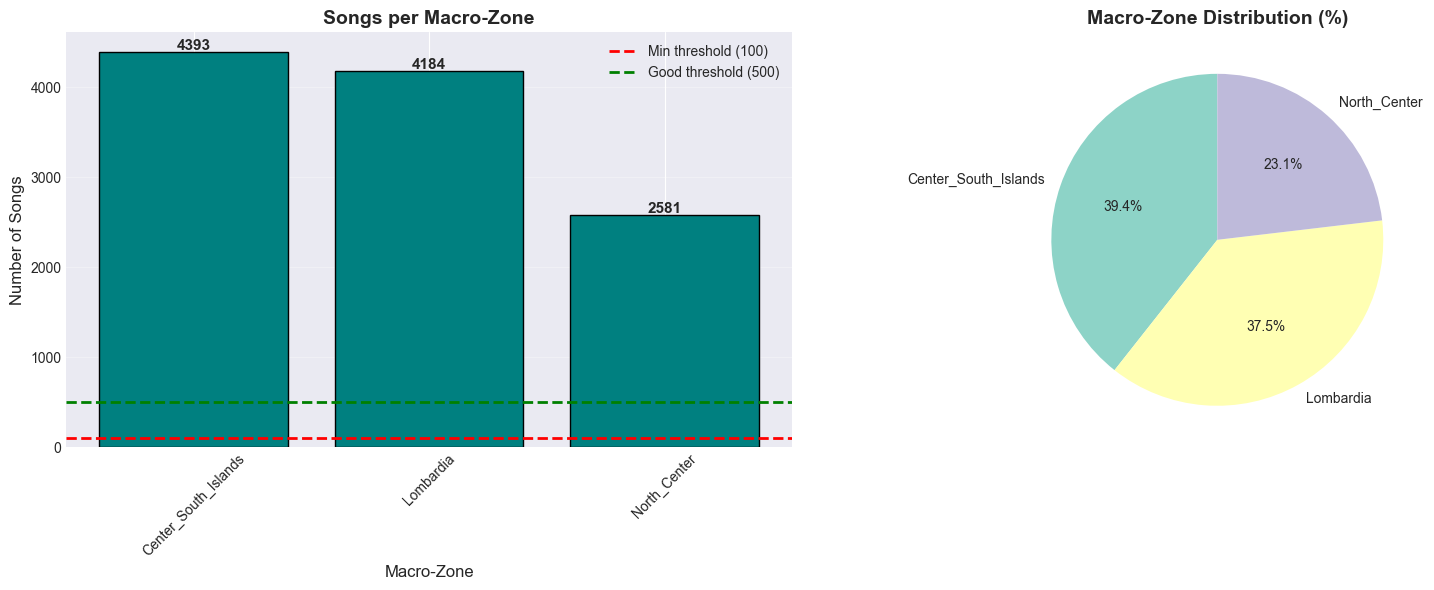

In [23]:
"""
Visualize the final macro-zone distribution to ensure balanced classes for modeling.
Check if any class has too few samples (potential imbalance issue).
"""

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].bar(macro_zone_counts.index, macro_zone_counts.values, color='teal', edgecolor='black')
axes[0].set_title('Songs per Macro-Zone', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Macro-Zone', fontsize=12)
axes[0].set_ylabel('Number of Songs', fontsize=12)
axes[0].axhline(y=100, color='red', linestyle='--', label='Min threshold (100)', linewidth=2)
axes[0].axhline(y=500, color='green', linestyle='--', label='Good threshold (500)', linewidth=2)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, (zone, count) in enumerate(macro_zone_counts.items()):
    axes[0].text(i, count + 20, str(count), ha='center', fontsize=11, fontweight='bold')

# Pie chart
colors = plt.cm.Set3(range(len(macro_zone_counts)))
axes[1].pie(macro_zone_counts, labels=macro_zone_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors)
axes[1].set_title('Macro-Zone Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('macro_zone_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [24]:
"""
Quantify class imbalance to determine if SMOTE or class weights will be needed during training.
Calculate imbalance ratio (majority class / minority class).
"""

imbalance_ratio = macro_zone_counts.max() / macro_zone_counts.min()

print("="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)
print(f"\nMajority class: {macro_zone_counts.index[0]} ({macro_zone_counts.iloc[0]} songs)")
print(f"Minority class: {macro_zone_counts.index[-1]} ({macro_zone_counts.iloc[-1]} songs)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 5:
    print("\nSEVERE IMBALANCE (>5:1) → SMOTE + Class Weights MANDATORY")
    imbalance_strategy = "SMOTE + Class Weights"
elif imbalance_ratio > 3:
    print("\nMODERATE IMBALANCE (3-5:1) → Stratified Split + Class Weights")
    imbalance_strategy = "Stratified + Class Weights"
else:
    print("\n✓ BALANCED (<3:1) → Stratified Split sufficient")
    imbalance_strategy = "Stratified Split Only"

print(f"\nRecommended strategy: {imbalance_strategy}")

CLASS IMBALANCE ANALYSIS

Majority class: Center_South_Islands (4393 songs)
Minority class: North_Center (2581 songs)
Imbalance ratio: 1.70:1

✓ BALANCED (<3:1) → Stratified Split sufficient

Recommended strategy: Stratified Split Only


In [25]:
"""
Remove columns not needed for modeling: artist ID, region (keep macro_zone), and region_source.
The final dataset should contain only features (X) and target variable (macro_zone).
"""

columns_to_drop_final = ['id_artist', 'region', 'region_source', 'name_artist']

cols_to_drop_final = [c for c in columns_to_drop_final if c in df_merged.columns]
df_merged = df_merged.drop(columns=cols_to_drop_final)

print(f"✓ Final merged dataset shape: {df_merged.shape}")
print(df_merged.columns.tolist())

✓ Final merged dataset shape: (11158, 22)
['swear_IT', 'swear_EN', 'year', 'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'zcr', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'duration_ms', 'explicit', 'macro_zone']


In [26]:
"""
Ensure all feature columns are numeric and properly typed for machine learning.
Convert 'explicit' to int, 'year' to numeric, and verify no string columns remain.
"""

# Convert explicit to binary integer
if 'explicit' in df_merged.columns:
    df_merged['explicit'] = df_merged['explicit'].astype(int)
    print("'explicit' converted to int")

# Convert year to numeric (handle any non-numeric values)
if 'year' in df_merged.columns:
    df_merged['year'] = pd.to_numeric(df_merged['year'], errors='coerce')
    median_year = df_merged['year'].median()
    df_merged['year'].fillna(median_year, inplace=True)
    print(f"'year' converted to numeric (median imputed: {int(median_year)})")

# Check data types
print("FINAL DATA TYPES:")
print(df_merged.dtypes)

# Verify no object columns remain (except macro_zone which is target)
object_cols = df_merged.select_dtypes(include='object').columns.tolist()
if len(object_cols) == 1 and object_cols[0] == 'macro_zone':
    print("\nAll features are numeric! Only 'macro_zone' is categorical (target).")
elif len(object_cols) > 1:
    print(f"\nWARNING: Unexpected object columns: {object_cols}")
else:
    print("\nWARNING: 'macro_zone' is missing!")

'explicit' converted to int
'year' converted to numeric (median imputed: 2017)
FINAL DATA TYPES:
swear_IT                  int64
swear_EN                  int64
year                    float64
n_sentences               int64
n_tokens                  int64
tokens_per_sent         float64
char_per_tok            float64
lexical_density         float64
avg_token_per_clause    float64
bpm                     float64
centroid                float64
rolloff                 float64
flux                    float64
rms                     float64
zcr                     float64
flatness                float64
spectral_complexity     float64
pitch                   float64
loudness                float64
duration_ms             float64
explicit                  int64
macro_zone               object
dtype: object

All features are numeric! Only 'macro_zone' is categorical (target).


/var/folders/29/j2385crd6f5dyk4l3185qktm0000gn/T/ipykernel_79300/1231324514.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['year'].fillna(median_year, inplace=True)


In [27]:
"""
Final check to ensure no missing values exist before splitting data for training.
Any remaining nulls will cause model training to fail.
"""

print("="*80)
print("FINAL MISSING VALUE CHECK")
print("="*80)

missing_final = df_merged.isnull().sum()
missing_final = missing_final[missing_final > 0]

if len(missing_final) > 0:
    print("\nERROR: Missing values found!")
    print(missing_final)
    print("\nYou must handle these before proceeding!")
else:
    print("\nSUCCESS: No missing values in final dataset!")

print(f"\nFinal dataset shape: {df_merged.shape}")
print(f"Ready for train-test split!")

FINAL MISSING VALUE CHECK

SUCCESS: No missing values in final dataset!

Final dataset shape: (11158, 22)
Ready for train-test split!


In [28]:
"""
Split the dataset into features (X) and target variable (y).
X contains all numeric features, y contains the macro-zone labels.
"""

# Separate features and target
X = df_merged.drop(columns=['macro_zone'])
y = df_merged['macro_zone']

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")

print(f"\nNumber of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {y.nunique()}")

# Save feature names for later use in XAI
feature_names = X.columns.tolist()



Features (X): (11158, 21)
Target (y): (11158,)

Number of features: 21
Number of samples: 11158
Number of classes: 3


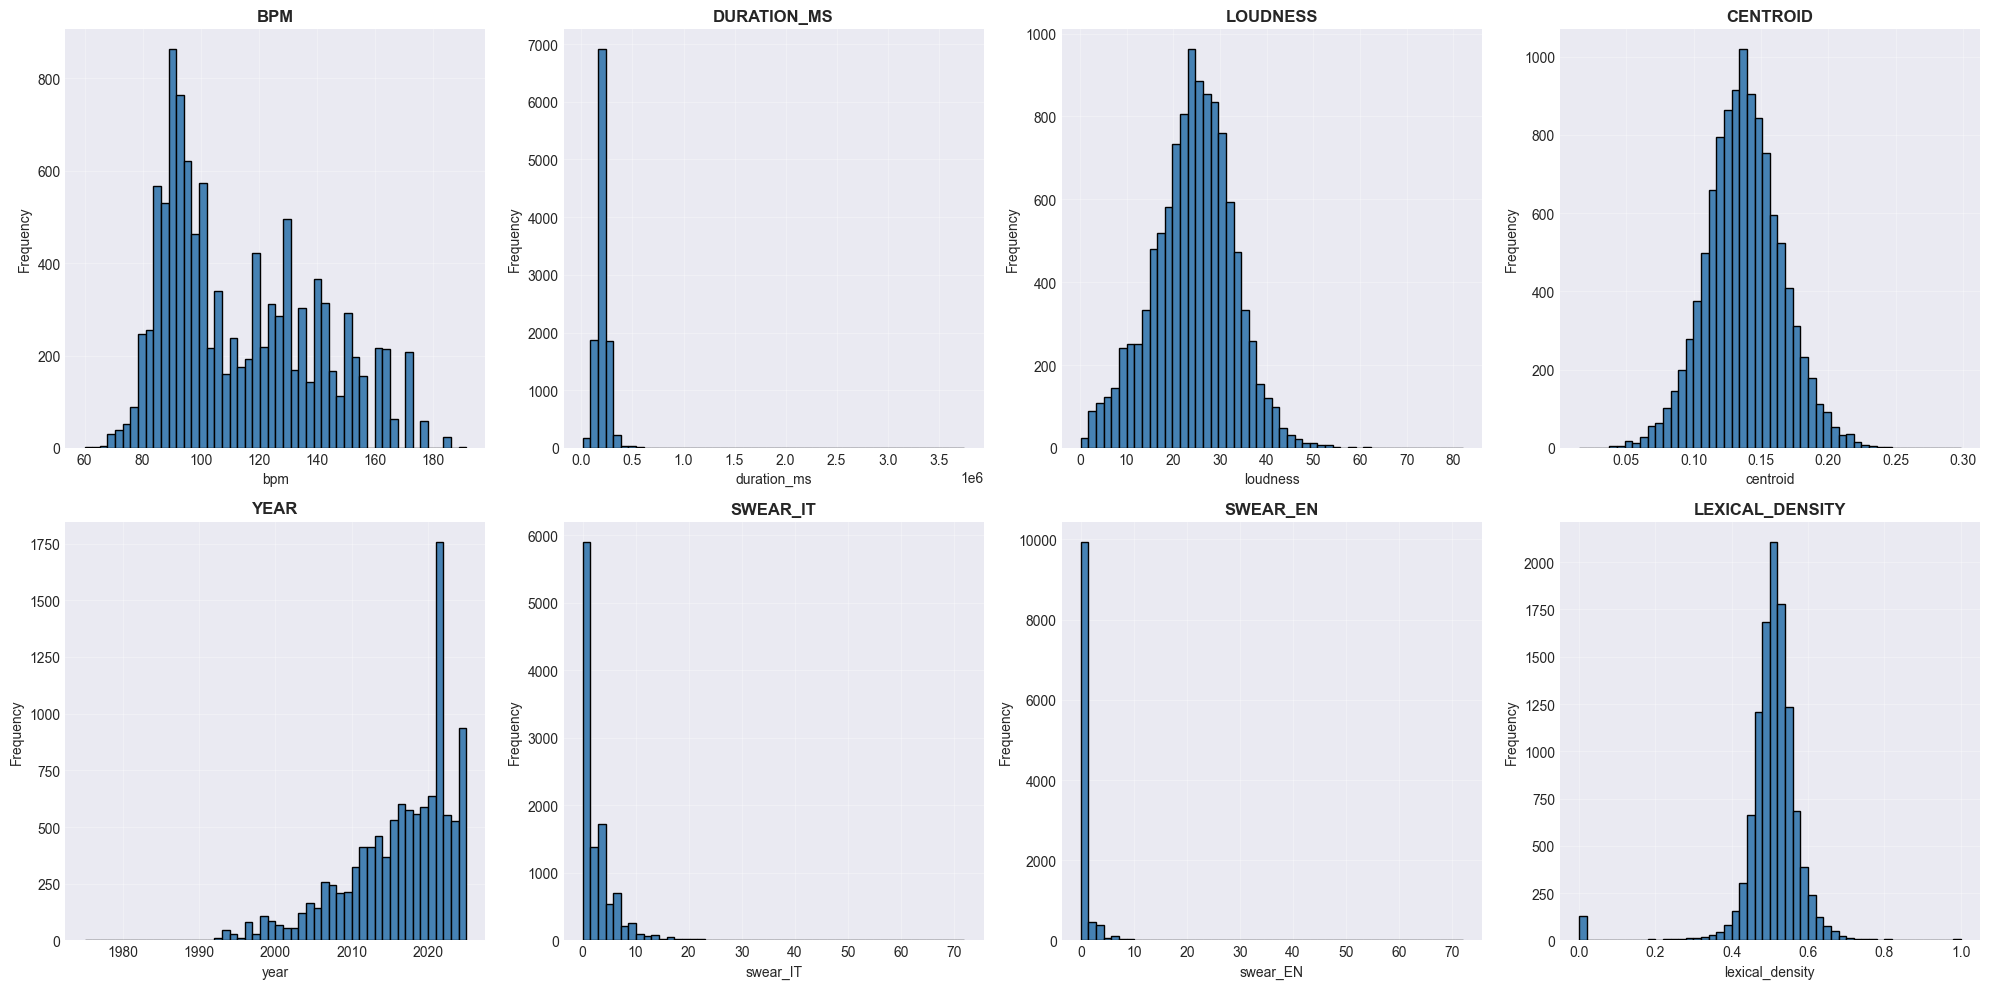

✓ Visualization saved: feature_distributions_before_scaling.png


In [29]:
"""
Visualize distributions of key features to understand their characteristics before scaling.
Check for skewness, outliers, and overall patterns in the data.
"""

# Select key features to visualize
key_features_viz = ['bpm', 'duration_ms', 'loudness', 'centroid', 'year', 
                    'swear_IT', 'swear_EN', 'lexical_density']

# Filter to only existing features
key_features_viz = [f for f in key_features_viz if f in X.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features_viz):
    if idx < len(axes):
        X[feature].hist(bins=50, ax=axes[idx], color='steelblue', edgecolor='black')
        axes[idx].set_title(f'{feature.upper()}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(alpha=0.3)

# Remove empty subplots
for idx in range(len(key_features_viz), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_distributions_before_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved: feature_distributions_before_scaling.png")

## #### ########### #########

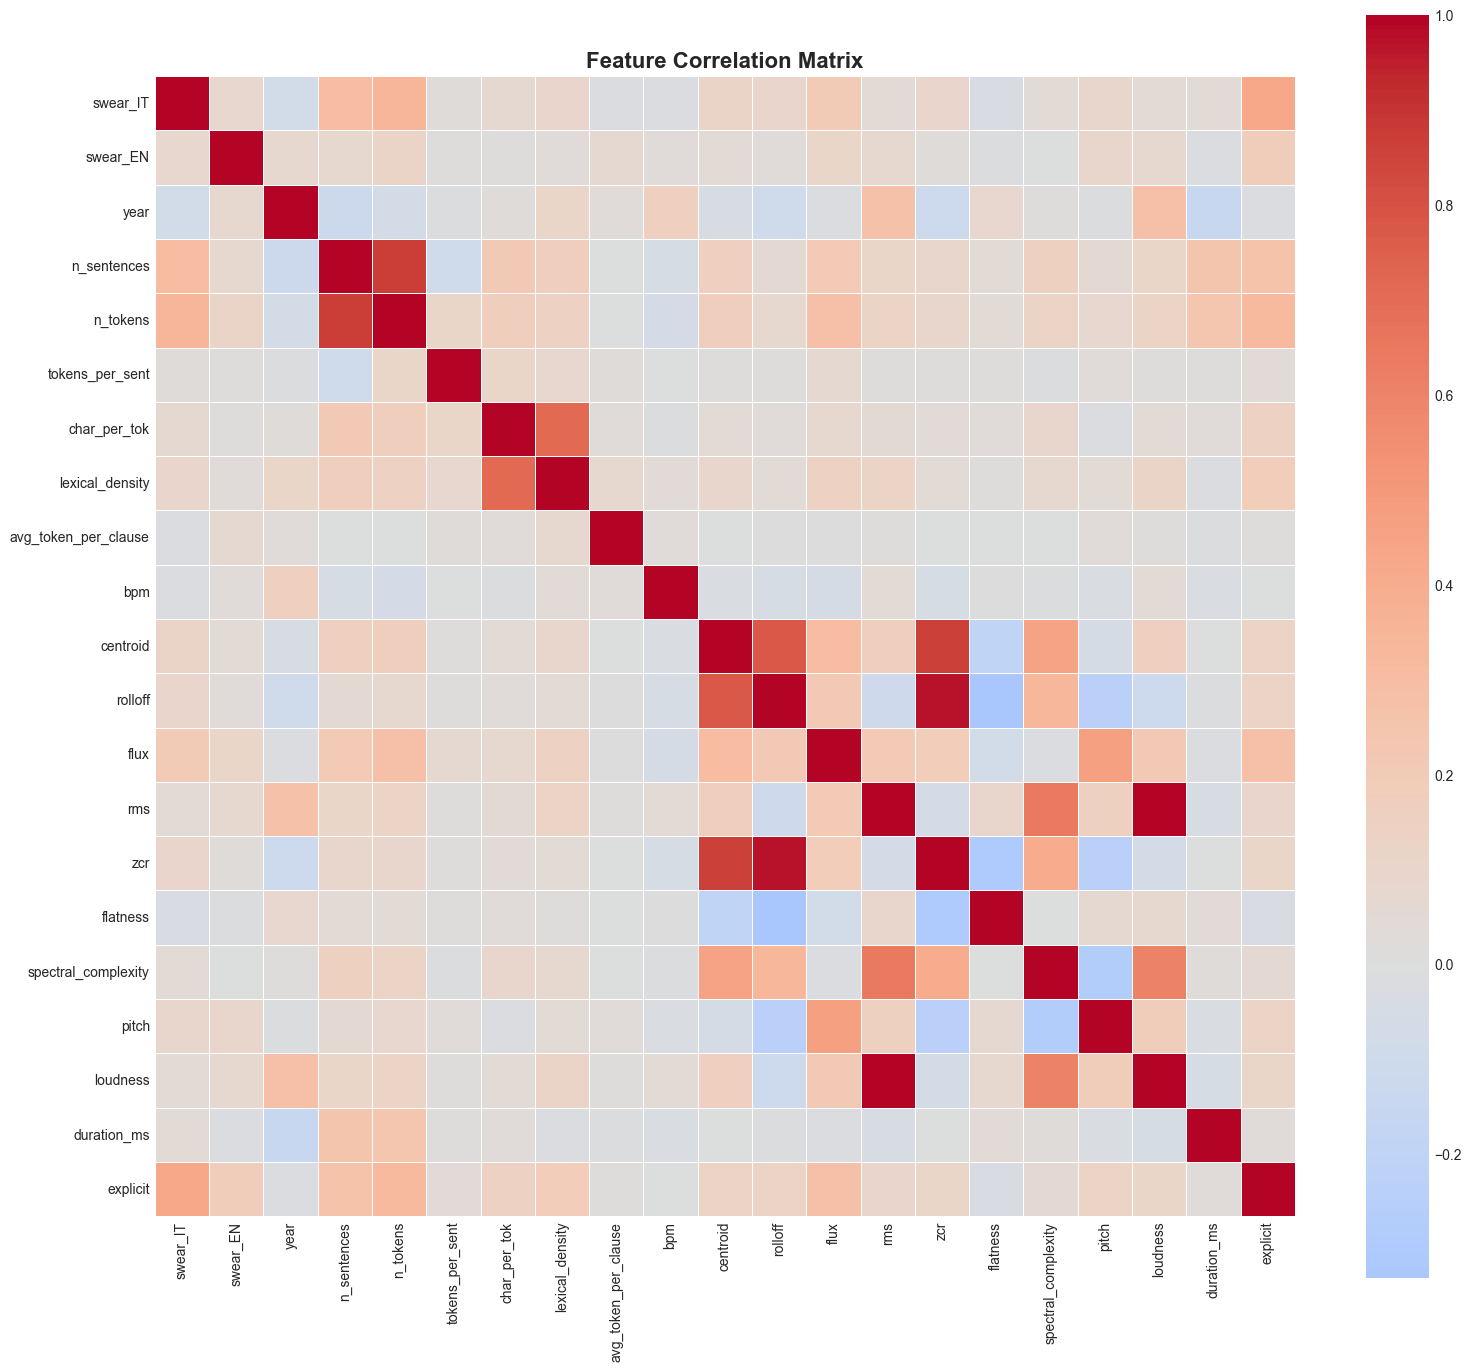


Highly correlated features (>0.9):
  Feature 1 Feature 2  Correlation
0   rolloff       zcr     0.969083
1       rms  loudness     0.995582
- Removing 'rms' (correlation > 0.9)
- Removing 'zcr' (correlation > 0.9)

FINAL PREPROCESSING COMPLETE
Dataset shape: 11158 samples, 19 features
Target classes: 3
Class distribution:
macro_zone
Center_South_Islands    4393
Lombardia               4184
North_Center            2581
Name: count, dtype: int64


In [30]:
"""
Analyze correlations between features to identify redundant or highly correlated features.
Remove highly correlated pairs to reduce multicollinearity before model training.
"""

# Calculate correlation matrix
correlation_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Find highly correlated pairs (>0.9)
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if len(high_corr) > 0:
    print("\nHighly correlated features (>0.9):")
    high_corr_df = pd.DataFrame(high_corr)
    print(high_corr_df)
    
    # Remove highly correlated features
    features_to_remove = ['rms', 'zcr']
    
    for feature in features_to_remove:
        if feature in X.columns:
            print(f"- Removing '{feature}' (correlation > 0.9)")
    
    X = X.drop(columns=features_to_remove)
    feature_names = X.columns.tolist()
    
else:
    print("\nNo highly correlated features (>0.9) found")

# Final dataset summary
print(f"\nFINAL PREPROCESSING COMPLETE")
print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target classes: {y.nunique()}")
print(f"Class distribution:")
print(y.value_counts())


# MODEL TRAINING ######

In [31]:

!pip install imbalanced-learn xgboost lightgbm optuna

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')


In [33]:
"""
Perform stratified train-test split to maintain class distribution in both training and test sets.
Apply feature scaling using StandardScaler for algorithms sensitive to feature magnitude.
"""

# Encode target labels to numeric format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class distribution before split:")
for i, class_name in enumerate(label_encoder.classes_):
    count = (y_encoded == i).sum()
    percentage = (count / len(y_encoded)) * 100
    print(f"{class_name}: {count} ({percentage:.1f}%)")

# Stratified train-test split (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_encoded
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed")
print(f"Feature means after scaling: {X_train_scaled.mean(axis=0)[:5]}...")
print(f"Feature stds after scaling: {X_train_scaled.std(axis=0)[:5]}...")

Class distribution before split:
Center_South_Islands: 4393 (39.4%)
Lombardia: 4184 (37.5%)
North_Center: 2581 (23.1%)

Train set: 7810 samples
Test set: 3348 samples

Feature scaling completed
Feature means after scaling: [-1.81957167e-17 -2.82033608e-17 -6.93438762e-15  8.46100825e-17
 -1.72859308e-17]...
Feature stds after scaling: [1. 1. 1. 1. 1.]...


In [34]:
"""
Calculate class weights to handle remaining imbalance during model training.
Even with good balance (1.7:1), slight weighting can improve minority class performance.
"""

# Calculate class weights
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print("Calculated class weights:")
for class_idx, weight in class_weight_dict.items():
    class_name = label_encoder.classes_[class_idx]
    print(f"{class_name}: {weight:.3f}")

# Check class distribution in train/test sets
print("\nTrain set class distribution:")
train_unique, train_counts = np.unique(y_train, return_counts=True)
for idx, count in zip(train_unique, train_counts):
    class_name = label_encoder.classes_[idx]
    percentage = (count / len(y_train)) * 100
    print(f"{class_name}: {count} ({percentage:.1f}%)")

print("\nTest set class distribution:")
test_unique, test_counts = np.unique(y_test, return_counts=True)
for idx, count in zip(test_unique, test_counts):
    class_name = label_encoder.classes_[idx]
    percentage = (count / len(y_test)) * 100
    print(f"{class_name}: {count} ({percentage:.1f}%)")

Calculated class weights:
Center_South_Islands: 0.847
Lombardia: 0.889
North_Center: 1.441

Train set class distribution:
Center_South_Islands: 3075 (39.4%)
Lombardia: 2929 (37.5%)
North_Center: 1806 (23.1%)

Test set class distribution:
Center_South_Islands: 1318 (39.4%)
Lombardia: 1255 (37.5%)
North_Center: 775 (23.1%)


In [35]:
"""
Define and train multiple machine learning models to compare performance.
Include both linear and tree-based algorithms for comprehensive comparison.
"""

# Define models with class weights where applicable
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    # 'Extra Trees': ExtraTreesClassifier(
    #     class_weight='balanced',
    #     n_estimators=100,
    #     random_state=42,
    #     n_jobs=-1
    # ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        n_estimators=100
    ),
    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        n_estimators=100
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=42,
        n_estimators=100,
        verbosity=-1
    ),
    'SVM': SVC(
        class_weight='balanced',
        random_state=42,
        probability=True
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

print(f"Defined {len(models)} models for comparison:")
for model_name in models.keys():
    print(f"- {model_name}")

Defined 7 models for comparison:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- SVM
- K-Nearest Neighbors


In [36]:
"""
Train all models and evaluate using cross-validation to get robust performance estimates.
Store results for comparison and visualization.
"""

cv_results = {}
cv_scores = {}

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training and evaluating models...")
print("="*60)

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Use scaled data for algorithms that need it
    if model_name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors']:
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    else:
        X_train_model = X_train
        X_test_model = X_test
    
    # Cross-validation
    cv_score = cross_val_score(
        model, X_train_model, y_train, 
        cv=cv, scoring='f1_weighted', n_jobs=-1
    )
    
    cv_scores[model_name] = cv_score
    cv_results[model_name] = {
        'mean_cv_score': cv_score.mean(),
        'std_cv_score': cv_score.std(),
        'model': model
    }
    
    print(f"CV F1-weighted: {cv_score.mean():.4f} (+/- {cv_score.std()*2:.4f})")

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*60)

# Sort models by performance
sorted_models = sorted(cv_results.items(), key=lambda x: x[1]['mean_cv_score'], reverse=True)

for i, (model_name, results) in enumerate(sorted_models, 1):
    mean_score = results['mean_cv_score']
    std_score = results['std_cv_score']
    print(f"{i}. {model_name}: {mean_score:.4f} (+/- {std_score*2:.4f})")

Training and evaluating models...

Training Logistic Regression...
CV F1-weighted: 0.3932 (+/- 0.0336)

Training Random Forest...
CV F1-weighted: 0.4653 (+/- 0.0060)

Training Gradient Boosting...
CV F1-weighted: 0.4488 (+/- 0.0203)

Training XGBoost...
CV F1-weighted: 0.4954 (+/- 0.0142)

Training LightGBM...
CV F1-weighted: 0.4850 (+/- 0.0116)

Training SVM...
CV F1-weighted: 0.4737 (+/- 0.0096)

Training K-Nearest Neighbors...
CV F1-weighted: 0.4243 (+/- 0.0127)

CROSS-VALIDATION RESULTS SUMMARY
1. XGBoost: 0.4954 (+/- 0.0142)
2. LightGBM: 0.4850 (+/- 0.0116)
3. SVM: 0.4737 (+/- 0.0096)
4. Random Forest: 0.4653 (+/- 0.0060)
5. Gradient Boosting: 0.4488 (+/- 0.0203)
6. K-Nearest Neighbors: 0.4243 (+/- 0.0127)
7. Logistic Regression: 0.3932 (+/- 0.0336)


In [37]:
"""
Train final models on full training set and evaluate on test set.
Generate detailed classification reports and confusion matrices.
"""

final_results = {}
trained_models = {}

print("Final model training and evaluation on test set...")
print("="*70)

for model_name, model in models.items():
    print(f"\nEvaluating {model_name} on test set...")
    
    # Select appropriate data (scaled or not)
    if model_name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors']:
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    else:
        X_train_model = X_train
        X_test_model = X_test
    
    # Train on full training set
    model.fit(X_train_model, y_train)
    trained_models[model_name] = model
    
    # Predict on test set
    y_pred = model.predict(X_test_model)
    y_pred_proba = model.predict_proba(X_test_model)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    # Store results
    final_results[model_name] = {
        'accuracy': accuracy,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")

# Find best model
best_model_name = max(final_results.keys(), key=lambda x: final_results[x]['f1_weighted'])
best_model = trained_models[best_model_name]

print(f"\n" + "="*70)
print(f"BEST MODEL: {best_model_name}")
print(f"Test F1-weighted: {final_results[best_model_name]['f1_weighted']:.4f}")


Final model training and evaluation on test set...

Evaluating Logistic Regression on test set...
Accuracy: 0.3967
F1-weighted: 0.3989
F1-macro: 0.3958

Evaluating Random Forest on test set...
Accuracy: 0.5003
F1-weighted: 0.4777
F1-macro: 0.4479

Evaluating Gradient Boosting on test set...
Accuracy: 0.4824
F1-weighted: 0.4614
F1-macro: 0.4340

Evaluating XGBoost on test set...
Accuracy: 0.4928
F1-weighted: 0.4864
F1-macro: 0.4705

Evaluating LightGBM on test set...
Accuracy: 0.5057
F1-weighted: 0.4955
F1-macro: 0.4765

Evaluating SVM on test set...
Accuracy: 0.4618
F1-weighted: 0.4643
F1-macro: 0.4550

Evaluating K-Nearest Neighbors on test set...
Accuracy: 0.4525
F1-weighted: 0.4341
F1-macro: 0.4070

BEST MODEL: LightGBM
Test F1-weighted: 0.4955


In [38]:
"""
Generate detailed classification report and confusion matrix for the best performing model.
"""

best_predictions = final_results[best_model_name]['predictions']

print(f"DETAILED RESULTS FOR BEST MODEL: {best_model_name}")
print("="*80)

# Classification report
print("\nClassification Report:")
target_names = label_encoder.classes_
print(classification_report(y_test, best_predictions, target_names=target_names))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_predictions)
print(cm)

# Confusion matrix with percentages
cm_normalized = confusion_matrix(y_test, best_predictions, normalize='true')
print("\nNormalized Confusion Matrix (%):")
print((cm_normalized * 100).round(1))

DETAILED RESULTS FOR BEST MODEL: LightGBM

Classification Report:
                      precision    recall  f1-score   support

Center_South_Islands       0.50      0.62      0.55      1318
           Lombardia       0.51      0.53      0.52      1255
        North_Center       0.50      0.27      0.35       775

            accuracy                           0.51      3348
           macro avg       0.50      0.47      0.48      3348
        weighted avg       0.51      0.51      0.50      3348


Confusion Matrix:
[[816 386 116]
 [493 664  98]
 [318 244 213]]

Normalized Confusion Matrix (%):
[[61.9 29.3  8.8]
 [39.3 52.9  7.8]
 [41.  31.5 27.5]]


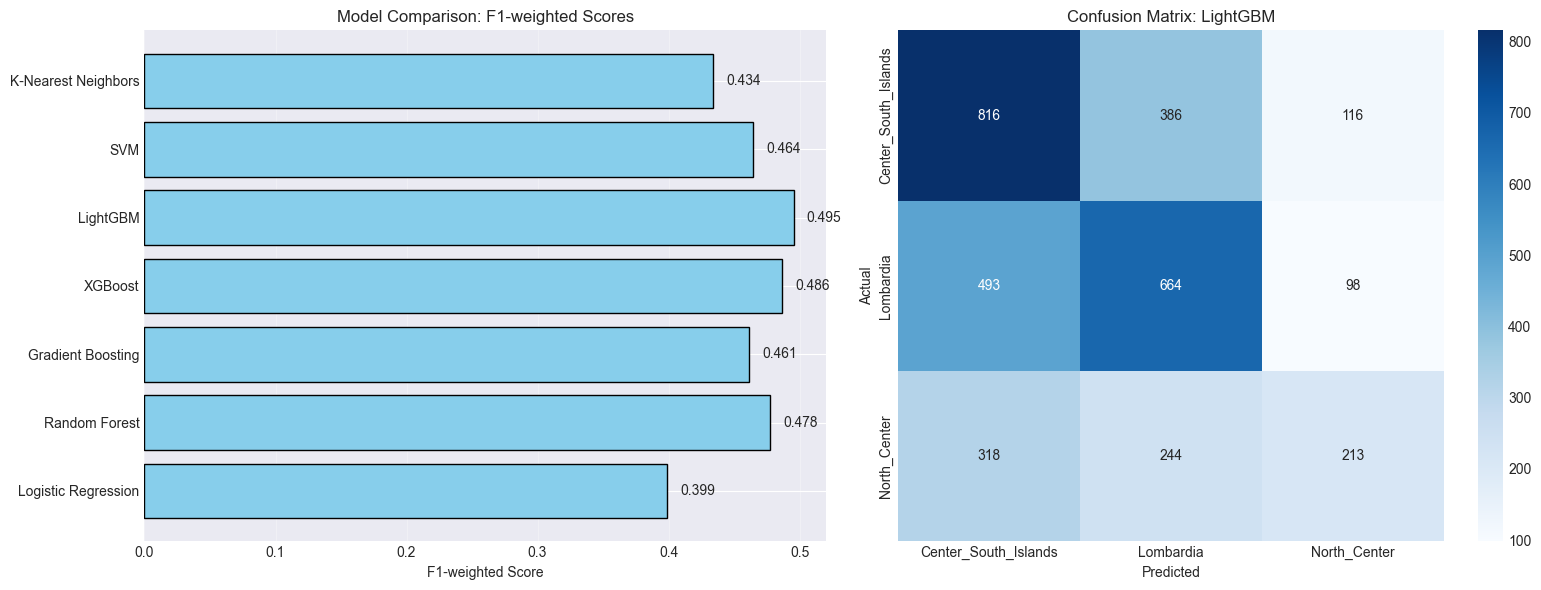

In [39]:
"""
Visualize model comparison results and confusion matrix for the best model.
"""

# Model comparison plot
model_names = list(final_results.keys())
f1_scores = [final_results[name]['f1_weighted'] for name in model_names]
accuracies = [final_results[name]['accuracy'] for name in model_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-weighted scores
axes[0].barh(model_names, f1_scores, color='skyblue', edgecolor='black')
axes[0].set_xlabel('F1-weighted Score')
axes[0].set_title('Model Comparison: F1-weighted Scores')
axes[0].grid(axis='x', alpha=0.3)
for i, score in enumerate(f1_scores):
    axes[0].text(score + 0.01, i, f'{score:.3f}', va='center')

# Confusion matrix heatmap
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix: {best_model_name}')

plt.tight_layout()
# plt.savefig('model_comparison_results.png', dpi=300, bbox_inches='tight')
plt.show()

# print("Visualization saved: model_comparison_results.png")

# HYPERPARAMETER TUNING

In [40]:
"""
Perform comprehensive hyperparameter tuning using GridSearchCV for the top 3 performing models.
Focus on LightGBM, XGBoost, and Random Forest to improve classification performance.
"""

from sklearn.model_selection import GridSearchCV
import time

# Define parameter grids for top 3 models
param_grids = {
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, -1],
        'learning_rate': [0.05, 0.1, 0.15],
        'num_leaves': [31, 50, 100],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'min_child_samples': [10, 20, 30]
    },
    
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5],
        'reg_alpha': [0, 0.1, 0.5]
    },
    
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }
}

# Models to tune
models_to_tune = {
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbosity=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
}


In [ ]:
"""
Execute grid search for each model and track the best parameters and scores.
Use 3-fold cross-validation for efficiency while maintaining reliability.
"""

tuned_results = {}
best_models = {}

for model_name, model in models_to_tune.items():
    print(f"\nTuning {model_name}...")
    print("-" * 50)
    
    # Start timing
    start_time = time.time()
    
    # Grid search with 3-fold CV for efficiency
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    # Select appropriate data (scaled vs original)
    if model_name in ['Logistic Regression', 'SVM']:
        X_tune = X_train_scaled
    else:
        X_tune = X_train
    
    # Fit grid search
    grid_search.fit(X_tune, y_train)
    
    # Store results
    tuned_results[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'best_estimator': grid_search.best_estimator_
    }
    best_models[model_name] = grid_search.best_estimator_
    
    # Calculate tuning time
    tuning_time = time.time() - start_time
    
    # Print results
    print(f"Best CV F1-weighted: {grid_search.best_score_:.4f}")
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Tuning time: {tuning_time:.1f} seconds")
    
    # Compare with baseline
    baseline_score = cv_results[model_name]['mean_cv_score']
    improvement = grid_search.best_score_ - baseline_score
    print(f"Improvement over baseline: {improvement:+.4f}")



Tuning LightGBM...
--------------------------------------------------
Fitting 3 folds for each of 2916 candidates, totalling 8748 fits


In [ ]:
"""
Evaluate tuned models on test set and compare with baseline performance.
Identify the best performing model after hyperparameter optimization.
"""

print("Evaluating tuned models on test set...")
print("="*70)

tuned_test_results = {}

for model_name, model in best_models.items():
    print(f"\nEvaluating tuned {model_name}...")
    
    # Select appropriate test data
    if model_name in ['Logistic Regression', 'SVM']:
        X_test_model = X_test_scaled
    else:
        X_test_model = X_test
    
    # Predict on test set
    y_pred_tuned = model.predict(X_test_model)
    y_pred_proba_tuned = model.predict_proba(X_test_model)
    
    # Calculate metrics
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    f1_weighted_tuned = f1_score(y_test, y_pred_tuned, average='weighted')
    f1_macro_tuned = f1_score(y_test, y_pred_tuned, average='macro')
    
    # Store results
    tuned_test_results[model_name] = {
        'accuracy': accuracy_tuned,
        'f1_weighted': f1_weighted_tuned,
        'f1_macro': f1_macro_tuned,
        'predictions': y_pred_tuned,
        'probabilities': y_pred_proba_tuned
    }
    
    # Compare with baseline
    baseline_f1 = final_results[model_name]['f1_weighted']
    improvement = f1_weighted_tuned - baseline_f1
    
    print(f"Baseline F1-weighted: {baseline_f1:.4f}")
    print(f"Tuned F1-weighted: {f1_weighted_tuned:.4f}")
    print(f"Improvement: {improvement:+.4f}")
    print(f"Accuracy: {accuracy_tuned:.4f}")
    print(f"F1-macro: {f1_macro_tuned:.4f}")

# Find best tuned model
best_tuned_model_name = max(tuned_test_results.keys(), 
                           key=lambda x: tuned_test_results[x]['f1_weighted'])
best_tuned_score = tuned_test_results[best_tuned_model_name]['f1_weighted']

print(f"\n{'='*70}")
print(f"BEST TUNED MODEL: {best_tuned_model_name}")
print(f"Test F1-weighted: {best_tuned_score:.4f}")
print("="*70)

In [ ]:
"""
Generate detailed classification reports and confusion matrices for the best models.
Compare baseline vs tuned performance comprehensively.
"""

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance Comparison: Baseline vs Tuned', fontsize=16)

# Plot 1: F1-weighted comparison
ax1 = axes[0, 0]
model_names = list(tuned_test_results.keys())
baseline_scores = [final_results[name]['f1_weighted'] for name in model_names]
tuned_scores = [tuned_test_results[name]['f1_weighted'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8)
bars2 = ax1.bar(x + width/2, tuned_scores, width, label='Tuned', alpha=0.8)

ax1.set_xlabel('Models')
ax1.set_ylabel('F1-weighted Score')
ax1.set_title('F1-weighted: Baseline vs Tuned')
ax1.set_xticks(x)
ax1.set_xticklabels([name.replace(' ', '\n') for name in model_names], rotation=0)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Plot 2: Improvement visualization
ax2 = axes[0, 1]
improvements = [tuned_scores[i] - baseline_scores[i] for i in range(len(model_names))]
colors = ['green' if imp > 0 else 'red' for imp in improvements]

bars = ax2.bar(x, improvements, color=colors, alpha=0.7)
ax2.set_xlabel('Models')
ax2.set_ylabel('F1-weighted Improvement')
ax2.set_title('Performance Improvement')
ax2.set_xticks(x)
ax2.set_xticklabels([name.replace(' ', '\n') for name in model_names], rotation=0)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(True, alpha=0.3)

# Add value labels
for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    ax2.annotate(f'{imp:+.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -15),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=8)

# Plot 3: Best model confusion matrix
ax3 = axes[0, 2]
best_predictions = tuned_test_results[best_tuned_model_name]['predictions']
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=macro_zone_mapping.values(),
            yticklabels=macro_zone_mapping.values())
ax3.set_title(f'Confusion Matrix: {best_tuned_model_name}')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# Plot 4: Class-wise F1 scores for best model
ax4 = axes[1, 0]
best_report = classification_report(y_test, best_predictions, 
                                   target_names=list(macro_zone_mapping.values()),
                                   output_dict=True)

classes = list(macro_zone_mapping.values())
class_f1_scores = [best_report[cls]['f1-score'] for cls in classes]

bars = ax4.bar(classes, class_f1_scores, alpha=0.8, color=['skyblue', 'lightcoral', 'lightgreen'])
ax4.set_ylabel('F1-score')
ax4.set_title(f'Class-wise F1-scores: {best_tuned_model_name}')
ax4.set_ylim(0, 1)

for bar, score in zip(bars, class_f1_scores):
    height = bar.get_height()
    ax4.annotate(f'{score:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

# Plot 5: Training time comparison (if available)
ax5 = axes[1, 1]
if 'grid_search_times' in globals():
    training_times = list(grid_search_times.values())
    bars = ax5.bar(model_names, training_times, alpha=0.8, color='orange')
    ax5.set_ylabel('Training Time (seconds)')
    ax5.set_title('Grid Search Training Times')
    ax5.set_xticks(x)
    ax5.set_xticklabels([name.replace(' ', '\n') for name in model_names], rotation=0)
    
    for bar, time_val in zip(bars, training_times):
        height = bar.get_height()
        ax5.annotate(f'{time_val:.1f}s',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
else:
    ax5.text(0.5, 0.5, 'Training times\nnot available', 
             ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Training Times')

# Plot 6: Overall performance summary
ax6 = axes[1, 2]
metrics = ['Accuracy', 'F1-weighted', 'F1-macro']
best_model_metrics = [
    tuned_test_results[best_tuned_model_name]['accuracy'],
    tuned_test_results[best_tuned_model_name]['f1_weighted'],
    tuned_test_results[best_tuned_model_name]['f1_macro']
]

bars = ax6.bar(metrics, best_model_metrics, alpha=0.8, color=['gold', 'silver', 'bronze'])
ax6.set_ylabel('Score')
ax6.set_title(f'Best Model Metrics: {best_tuned_model_name}')
ax6.set_ylim(0, 1)

for bar, score in zip(bars, best_model_metrics):
    height = bar.get_height()
    ax6.annotate(f'{score:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print detailed classification report for best model
print(f"\nDetailed Classification Report for {best_tuned_model_name}:")
print("="*70)
print(classification_report(y_test, best_predictions, 
                           target_names=list(macro_zone_mapping.values())))

# Summary statistics
print(f"\nSUMMARY OF HYPERPARAMETER TUNING RESULTS:")
print("="*70)
for model_name in model_names:
    baseline_f1 = final_results[model_name]['f1_weighted']
    tuned_f1 = tuned_test_results[model_name]['f1_weighted']
    improvement = tuned_f1 - baseline_f1
    print(f"{model_name:<20} | Baseline: {baseline_f1:.4f} | Tuned: {tuned_f1:.4f} | Improvement: {improvement:+.4f}")

print("="*70)
overall_best_baseline = max(final_results.values(), key=lambda x: x['f1_weighted'])['f1_weighted']
overall_best_tuned = best_tuned_score
overall_improvement = overall_best_tuned - overall_best_baseline

print(f"Best Baseline Score: {overall_best_baseline:.4f}")
print(f"Best Tuned Score: {overall_best_tuned:.4f}")
print(f"Overall Improvement: {overall_improvement:+.4f}")
print("="*70)